Running KERAS Implementation

XOR Dataset
Input (X):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]

KERAS IMPLEMENTATION

Building Model...


C:\Users\adith\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)                 │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


Compiling Model...

Training Model...
Final Loss: 0.0002
Final Accuracy: 1.0000

Predictions

Input		Expected	Predicted	Probability
------------------------------------------------------------
[0. 0.]	0		0		0.0007
[0. 1.]	1		1		0.9999
[1. 0.]	1		1		0.9999
[1. 1.]	0		0		0.0001

Final Accuracy: 100.00%

Results saved as 'keras_xor_results.png'


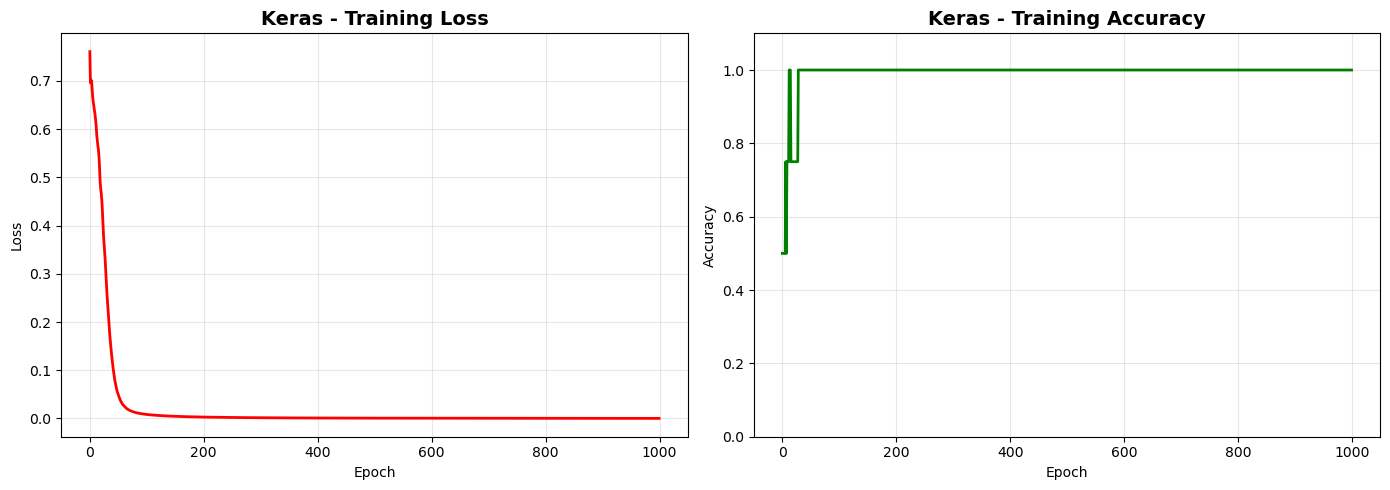

Decision boundary saved as 'keras_xor_boundary.png'


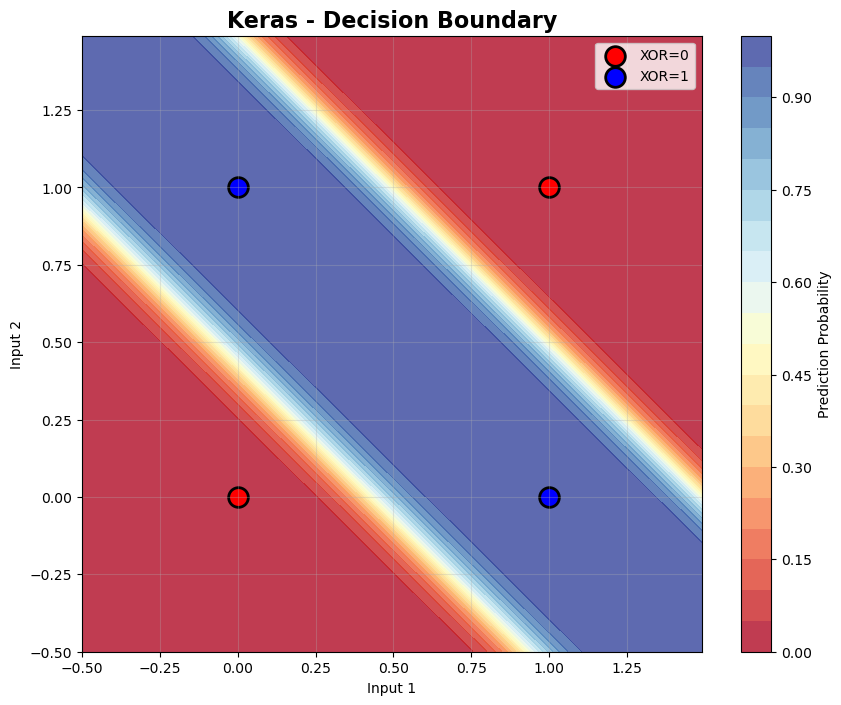


EXPERIMENT COMPLETE!


In [5]:
"""
XOR Boolean Function Learning Using MLP - ALL THREE IMPLEMENTATIONS
====================================================================
1. Keras Implementation
2. PyTorch Implementation  
3. TensorFlow Low-Level Implementation
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

IMPLEMENTATION = "keras"  # Options: "keras", "pytorch", "tensorflow"

print("=" * 80)
print(f"Running {IMPLEMENTATION.upper()} Implementation")
print("=" * 80)
print()


print("=" * 60)
print("XOR Dataset")
print("=" * 60)

X_data = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=np.float32)

y_data = np.array([[0],
                   [1],
                   [1],
                   [0]], dtype=np.float32)

print("Input (X):")
print(X_data)
print("\nOutput (y):")
print(y_data)
print()


# IMPLEMENTATION 1: KERAS


if IMPLEMENTATION == "keras":
    from tensorflow import keras
    from tensorflow.keras import layers
    
    print("=" * 60)
    print("KERAS IMPLEMENTATION")
    print("=" * 60)
    
    # Convert to numpy arrays
    X = X_data
    y = y_data
    
    # Build model
    print("\nBuilding Model...")
    model = keras.Sequential([
        layers.Dense(4, activation='relu', input_shape=(2,), name='hidden_layer'),
        layers.Dense(1, activation='sigmoid', name='output_layer')
    ])
    
    model.summary()
    
    # Compile
    print("\nCompiling Model...")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.1),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    print("\nTraining Model...")
    history = model.fit(
        X, y,
        epochs=1000,
        batch_size=4,
        verbose=0
    )
    
    print(f"Final Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Accuracy: {history.history['accuracy'][-1]:.4f}")
    
    # Predict
    print("\n" + "=" * 60)
    print("Predictions")
    print("=" * 60)
    predictions = model.predict(X, verbose=0)
    predicted_classes = (predictions > 0.5).astype(int)
    
    print("\nInput\t\tExpected\tPredicted\tProbability")
    print("-" * 60)
    for i in range(len(X)):
        print(f"{X[i]}\t{y[i][0]:.0f}\t\t{predicted_classes[i][0]}\t\t{predictions[i][0]:.4f}")
    
    accuracy = accuracy_score(y, predicted_classes)
    print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], linewidth=2, color='red')
    axes[0].set_title('Keras - Training Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['accuracy'], linewidth=2, color='green')
    axes[1].set_title('Keras - Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('keras_xor_results.png', dpi=300)
    print("\nResults saved as 'keras_xor_results.png'")
    plt.show()
    
    # Decision Boundary
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.8)
    plt.colorbar(label='Prediction Probability')
    
    colors = ['red', 'blue']
    for i in range(len(X)):
        plt.scatter(X[i, 0], X[i, 1], 
                    c=colors[int(y[i, 0])], 
                    s=200, 
                    edgecolors='black', 
                    linewidths=2,
                    label=f'XOR={int(y[i, 0])}' if i < 2 else '')
    
    plt.title('Keras - Decision Boundary', fontsize=16, fontweight='bold')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('keras_xor_boundary.png', dpi=300)
    print("Decision boundary saved as 'keras_xor_boundary.png'")
    plt.show()


# IMPLEMENTATION 2: PYTORCH


elif IMPLEMENTATION == "pytorch":
    import torch
    import torch.nn as nn
    import torch.optim as optim
    
    print("=" * 60)
    print("PYTORCH IMPLEMENTATION")
    print("=" * 60)
    
    # Convert to PyTorch tensors
    X = torch.tensor(X_data, dtype=torch.float32)
    y = torch.tensor(y_data, dtype=torch.float32)
    
    # Build model
    class XORNet(nn.Module):
        def __init__(self, hidden_neurons=4):
            super(XORNet, self).__init__()
            self.hidden = nn.Linear(2, hidden_neurons)
            self.output = nn.Linear(hidden_neurons, 1)
            
        def forward(self, x):
            x = torch.relu(self.hidden(x))
            x = torch.sigmoid(self.output(x))
            return x
    
    print("\nBuilding Model...")
    model = XORNet(hidden_neurons=4)
    print(model)
    
    # Define loss and optimizer
    print("\nSetting up training...")
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.1)
    
    # Train
    print("\nTraining Model...")
    epochs = 1000
    loss_history = []
    accuracy_history = []
    
    for epoch in range(epochs):
        outputs = model(X)
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        
        with torch.no_grad():
            predicted = (outputs > 0.5).float()
            accuracy = (predicted == y).float().mean().item()
            accuracy_history.append(accuracy)
        
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}')
    
    print(f"\nFinal Loss: {loss_history[-1]:.4f}")
    print(f"Final Accuracy: {accuracy_history[-1]:.4f}")
    
    # Predict
    print("\n" + "=" * 60)
    print("Predictions")
    print("=" * 60)
    
    model.eval()
    with torch.no_grad():
        predictions = model(X)
        predicted_classes = (predictions > 0.5).float()
    
    print("\nInput\t\tExpected\tPredicted\tProbability")
    print("-" * 60)
    for i in range(len(X)):
        print(f"{X[i].numpy()}\t{y[i].item():.0f}\t\t{predicted_classes[i].item():.0f}\t\t{predictions[i].item():.4f}")
    
    accuracy = (predicted_classes == y).float().mean().item()
    print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(loss_history, linewidth=2, color='red')
    axes[0].set_title('PyTorch - Training Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(accuracy_history, linewidth=2, color='green')
    axes[1].set_title('PyTorch - Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pytorch_xor_results.png', dpi=300)
    print("\nResults saved as 'pytorch_xor_results.png'")
    plt.show()
    
    # Decision Boundary
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    model.eval()
    with torch.no_grad():
        mesh_input = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        Z = model(mesh_input).numpy()
        Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.8)
    plt.colorbar(label='Prediction Probability')
    
    colors = ['red', 'blue']
    X_np = X.numpy()
    y_np = y.numpy()
    for i in range(len(X_np)):
        plt.scatter(X_np[i, 0], X_np[i, 1], 
                    c=colors[int(y_np[i, 0])], 
                    s=200, 
                    edgecolors='black', 
                    linewidths=2,
                    label=f'XOR={int(y_np[i, 0])}' if i < 2 else '')
    
    plt.title('PyTorch - Decision Boundary', fontsize=16, fontweight='bold')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('pytorch_xor_boundary.png', dpi=300)
    print("Decision boundary saved as 'pytorch_xor_boundary.png'")
    plt.show()


# IMPLEMENTATION 3: TENSORFLOW LOW-LEVEL


elif IMPLEMENTATION == "tensorflow":
    import tensorflow as tf
    
    print("=" * 60)
    print("TENSORFLOW LOW-LEVEL IMPLEMENTATION")
    print("=" * 60)
    
    tf.random.set_seed(42)
    
    X = X_data
    y = y_data
    
    # Initialize weights
    print("\nInitializing Model Parameters...")
    input_size = 2
    hidden_size = 4
    output_size = 1
    
    W1 = tf.Variable(tf.random.normal([input_size, hidden_size], stddev=0.5), dtype=tf.float32)
    b1 = tf.Variable(tf.zeros([hidden_size]), dtype=tf.float32)
    W2 = tf.Variable(tf.random.normal([hidden_size, output_size], stddev=0.5), dtype=tf.float32)
    b2 = tf.Variable(tf.zeros([output_size]), dtype=tf.float32)
    
    print(f"W1 shape: {W1.shape}")
    print(f"b1 shape: {b1.shape}")
    print(f"W2 shape: {W2.shape}")
    print(f"b2 shape: {b2.shape}")
    
    # Forward pass function
    def forward_pass(X):
        z1 = tf.matmul(X, W1) + b1
        hidden = tf.nn.relu(z1)
        z2 = tf.matmul(hidden, W2) + b2
        output = tf.nn.sigmoid(z2)
        return output, hidden
    
    # Loss function
    def compute_loss(y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)
        loss = -tf.reduce_mean(
            y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)
        )
        return loss
    
    # Optimizer
    print("\nSetting up optimizer...")
    optimizer = tf.optimizers.Adam(learning_rate=0.1)
    
    # Train
    print("\nTraining Model...")
    epochs = 1000
    loss_history = []
    accuracy_history = []
    
    X_tf = tf.constant(X, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)
    
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            predictions, hidden = forward_pass(X_tf)
            loss = compute_loss(y_tf, predictions)
        
        gradients = tape.gradient(loss, [W1, b1, W2, b2])
        optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
        
        loss_history.append(loss.numpy())
        
        predicted_classes = tf.cast(predictions > 0.5, tf.float32)
        accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, y_tf), tf.float32))
        accuracy_history.append(accuracy.numpy())
        
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.numpy():.4f}, Accuracy: {accuracy.numpy():.4f}')
    
    print(f"\nFinal Loss: {loss_history[-1]:.4f}")
    print(f"Final Accuracy: {accuracy_history[-1]:.4f}")
    
    # Predict
    print("\n" + "=" * 60)
    print("Predictions")
    print("=" * 60)
    
    final_predictions, _ = forward_pass(X_tf)
    predicted_classes = tf.cast(final_predictions > 0.5, tf.float32)
    
    print("\nInput\t\tExpected\tPredicted\tProbability")
    print("-" * 60)
    for i in range(len(X)):
        print(f"{X[i]}\t{y[i][0]:.0f}\t\t{predicted_classes[i][0].numpy():.0f}\t\t{final_predictions[i][0].numpy():.4f}")
    
    final_accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, y_tf), tf.float32))
    print(f"\nFinal Accuracy: {final_accuracy.numpy() * 100:.2f}%")
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(loss_history, linewidth=2, color='red')
    axes[0].set_title('TensorFlow - Training Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(accuracy_history, linewidth=2, color='green')
    axes[1].set_title('TensorFlow - Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('tensorflow_xor_results.png', dpi=300)
    print("\nResults saved as 'tensorflow_xor_results.png'")
    plt.show()
    
    # Decision Boundary
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    mesh_input = tf.constant(np.c_[xx.ravel(), yy.ravel()], dtype=tf.float32)
    Z, _ = forward_pass(mesh_input)
    Z = Z.numpy().reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.8)
    plt.colorbar(label='Prediction Probability')
    
    colors = ['red', 'blue']
    for i in range(len(X)):
        plt.scatter(X[i, 0], X[i, 1], 
                    c=colors[int(y[i, 0])], 
                    s=200, 
                    edgecolors='black', 
                    linewidths=2,
                    label=f'XOR={int(y[i, 0])}' if i < 2 else '')
    
    plt.title('TensorFlow - Decision Boundary', fontsize=16, fontweight='bold')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('tensorflow_xor_boundary.png', dpi=300)
    print("Decision boundary saved as 'tensorflow_xor_boundary.png'")
    plt.show()

else:
    print(f"Invalid IMPLEMENTATION value: {IMPLEMENTATION}")
    print("Choose from: 'keras', 'pytorch', or 'tensorflow'")

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETE!")
print("=" * 80)